# 科学数据与可信基线：随机划分为什么会过于乐观

## Goal

用一个可完全复现的“分组科学数据”实验比较随机划分与按科学实体分组的划分。重点不是追求高分，而是检查评价问题是否与目标问题一致。

对应正文：[第 2 章：科学数据与可信基线](../../docs/part1-ai-foundations/chapter2.md)。

## Setup

### Key Assumptions

- 每个 `scaffold` 模拟一个分子骨架，同一骨架下有多个类似物；
- 骨架带来未被两个连续描述符完全解释的系统效应；
- 随机划分允许同一骨架同时出现在训练和测试中，回答“预测已见骨架的新类似物”；
- 分组划分把完整骨架留作测试，回答“预测未见骨架”。

数据是教学用合成数据，不代表任何真实化学测量，也不能用于材料或药物决策。

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 20260810
rng = np.random.default_rng(RANDOM_SEED)

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "seed": RANDOM_SEED,
})

{'python': '3.12.2', 'numpy': '2.4.0', 'pandas': '2.3.3', 'scikit_learn': '1.8.0', 'seed': 20260810}


## Steps

### 1. Generate grouped scientific observations

In [2]:
n_scaffolds = 60
analogues_per_scaffold = 8
scaffold_names = np.array([f"S{i:02d}" for i in range(n_scaffolds)])
scaffold_effect = rng.normal(0.0, 2.0, size=n_scaffolds)

rows = []
for scaffold_index, scaffold in enumerate(scaffold_names):
    for analogue in range(analogues_per_scaffold):
        descriptor_1 = rng.normal()
        descriptor_2 = rng.uniform(-1.0, 1.0)
        measurement_noise = rng.normal(0.0, 0.25)
        target = (
            1.8 * descriptor_1
            - 1.1 * descriptor_2
            + scaffold_effect[scaffold_index]
            + measurement_noise
        )
        rows.append(
            {
                "scaffold": scaffold,
                "analogue": analogue,
                "descriptor_1": descriptor_1,
                "descriptor_2": descriptor_2,
                "target": target,
            }
        )

data = pd.DataFrame(rows)
print(f"rows={len(data)}, scaffolds={data['scaffold'].nunique()}")
data.head()

rows=480, scaffolds=60


,scaffold,analogue,descriptor_1,descriptor_2,target
0,S00,0,-1.545956,0.259357,-2.114064
1,S00,1,-0.335013,-0.611301,1.388080
2,S00,2,0.087343,-0.573453,1.657114
3,S00,3,-1.122358,-0.966316,-0.082466
4,S00,4,0.213562,0.997429,0.386739


### 2. Audit grain, missingness, duplicates, and group sizes

In [3]:
audit = {
    "rows": len(data),
    "unique_scaffold_analogue_pairs": data[["scaffold", "analogue"]].drop_duplicates().shape[0],
    "missing_cells": int(data.isna().sum().sum()),
    "min_group_size": int(data.groupby("scaffold").size().min()),
    "max_group_size": int(data.groupby("scaffold").size().max()),
}
assert audit["rows"] == audit["unique_scaffold_analogue_pairs"]
assert audit["missing_cells"] == 0
print(audit)

{'rows': 480, 'unique_scaffold_analogue_pairs': 480, 'missing_cells': 0, 'min_group_size': 8, 'max_group_size': 8}


### 3. Build a model ladder with the same preprocessing boundary

In [4]:
feature_columns = ["scaffold", "descriptor_1", "descriptor_2"]
numeric_columns = ["descriptor_1", "descriptor_2"]
categorical_columns = ["scaffold"]

def make_preprocessing():
    return ColumnTransformer(
        [
            ("numeric", StandardScaler(), numeric_columns),
            (
                "scaffold",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_columns,
            ),
        ]
    )

def make_models(seed):
    return {
        "mean": DummyRegressor(strategy="mean"),
        "ridge": make_pipeline(make_preprocessing(), Ridge(alpha=1.0)),
        "forest": make_pipeline(
            make_preprocessing(),
            RandomForestRegressor(
                n_estimators=160,
                min_samples_leaf=3,
                random_state=seed,
                n_jobs=1,
            ),
        ),
        "mlp": make_pipeline(
            make_preprocessing(),
            MLPRegressor(
                hidden_layer_sizes=(20,),
                activation="tanh",
                solver="adam",
                alpha=0.1,
                max_iter=2000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=30,
                learning_rate_init=0.01,
                tol=1e-4,
                random_state=seed,
            ),
        ),
    }

def evaluate_split(train_indices, test_indices, split_name, repeat):
    train = data.iloc[train_indices]
    test = data.iloc[test_indices]
    shared_groups = set(train["scaffold"]) & set(test["scaffold"])
    rows = []
    prediction_rows = []
    for model_name, model in make_models(RANDOM_SEED + repeat).items():
        model.fit(train[feature_columns], train["target"])
        prediction = model.predict(test[feature_columns])
        rows.append(
            {
                "repeat": repeat,
                "split": split_name,
                "model": model_name,
                "train_rows": len(train),
                "test_rows": len(test),
                "shared_scaffolds": len(shared_groups),
                "mae": mean_absolute_error(test["target"], prediction),
                "rmse": mean_squared_error(test["target"], prediction) ** 0.5,
            }
        )
        if repeat == 0:
            prediction_rows.extend(
                {
                    "split": split_name,
                    "model": model_name,
                    "scaffold": scaffold,
                    "observed": observed,
                    "predicted": predicted,
                }
                for scaffold, observed, predicted in zip(
                    test["scaffold"], test["target"], prediction
                )
            )
    return rows, prediction_rows

### 4. Repeat random and scaffold-held-out evaluation under matched budgets

In [5]:
all_indices = np.arange(len(data))
n_repeats = 6
result_rows = []
prediction_rows = []
for repeat in range(n_repeats):
    split_seed = RANDOM_SEED + repeat
    random_train, random_test = train_test_split(
        all_indices, test_size=0.25, random_state=split_seed
    )
    group_splitter = GroupShuffleSplit(
        n_splits=1, test_size=0.25, random_state=split_seed
    )
    grouped_train, grouped_test = next(
        group_splitter.split(data, groups=data["scaffold"])
    )
    for split_name, train_indices, test_indices in [
        ("Random row split", random_train, random_test),
        ("Held-out scaffold split", grouped_train, grouped_test),
    ]:
        rows, predictions = evaluate_split(
            train_indices, test_indices, split_name, repeat
        )
        result_rows.extend(rows)
        prediction_rows.extend(predictions)

results = pd.DataFrame(result_rows)
predictions = pd.DataFrame(prediction_rows)
assert (results.loc[results["split"] == "Held-out scaffold split", "shared_scaffolds"] == 0).all()
summary = (
    results.groupby(["split", "model"])[["mae", "rmse"]]
    .agg(["mean", "std"])
    .round(3)
)
summary

mae          rmse       
                                 mean    std   mean    std
split                   model                             
Held-out scaffold split forest  1.809  0.145  2.220  0.179
                        mean    2.338  0.217  2.886  0.213
                        mlp     1.831  0.270  2.278  0.306
                        ridge   1.767  0.177  2.183  0.217
Random row split        forest  1.657  0.100  2.062  0.104
                        mean    2.345  0.117  2.863  0.130
                        mlp     0.251  0.029  0.316  0.032
                        ridge   0.344  0.028  0.434  0.037

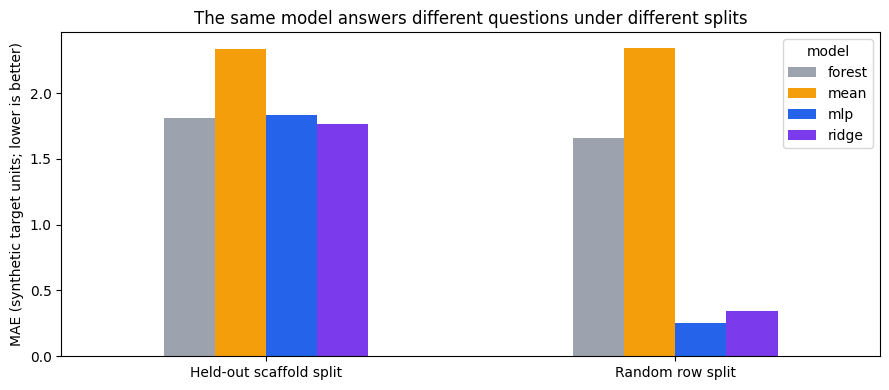

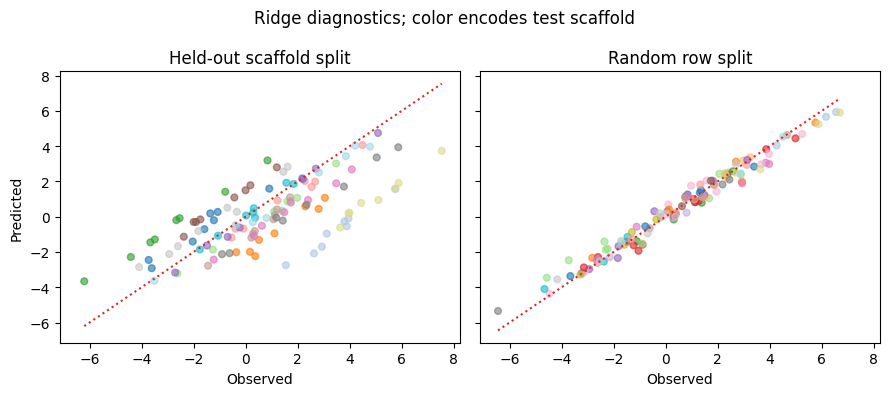

In [6]:
plot_data = results.groupby(["split", "model"])["mae"].mean().unstack()
ax = plot_data.plot(
    kind="bar", figsize=(9, 4), color=["#9ca3af", "#f59e0b", "#2563eb", "#7c3aed"]
)
ax.set_title("The same model answers different questions under different splits")
ax.set_ylabel("MAE (synthetic target units; lower is better)")
ax.set_xlabel("")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ridge_predictions = predictions[predictions["model"] == "ridge"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for axis, (split_name, frame) in zip(axes, ridge_predictions.groupby("split")):
    group_codes = pd.factorize(frame["scaffold"])[0]
    axis.scatter(
        frame["observed"], frame["predicted"], c=group_codes,
        cmap="tab20", alpha=0.62, s=24
    )
    limits = [
        min(frame["observed"].min(), frame["predicted"].min()),
        max(frame["observed"].max(), frame["predicted"].max()),
    ]
    axis.plot(limits, limits, color="#dc2626", linestyle=":")
    axis.set_title(split_name)
    axis.set_xlabel("Observed")
axes[0].set_ylabel("Predicted")
fig.suptitle("Ridge diagnostics; color encodes test scaffold")
plt.tight_layout()
plt.show()

## Checks

- 分组划分的训练与测试骨架交集必须为零；
- 两种划分使用同一目标、特征、模型、重复数和测试比例；
- 同时报告 MAE、RMSE 与重复间离散度，不把两种问题伪装成同一总体；
- 如果随机划分明显更好，合理解释是它可复用已见骨架效应，而不是模型普遍更懂化学。

In [7]:
assert set(results["model"]) == {"mean", "ridge", "forest", "mlp"}
assert results.groupby(["split", "model"]).size().eq(n_repeats).all()
assert np.isfinite(results[["mae", "rmse"]].to_numpy()).all()
ridge_means = results[results["model"] == "ridge"].groupby("split")["mae"].mean()
print(f"随机划分 Ridge 平均 MAE: {ridge_means['Random row split']:.3f}")
print(f"骨架分组 Ridge 平均 MAE: {ridge_means['Held-out scaffold split']:.3f}")
print(
    "RESULT_CONTRACT scientific-data "
    f"random_ridge_mean_mae={ridge_means['Random row split']:.6f} "
    f"grouped_ridge_mean_mae={ridge_means['Held-out scaffold split']:.6f}"
)
print("CONTRACT scientific-data: models=4 repeats=6 grouped_overlap=0 metrics=mae,rmse")
print("本次确定性合成实验的差值不应外推为真实分子数据的固定幅度。")

随机划分 Ridge 平均 MAE: 0.344
骨架分组 Ridge 平均 MAE: 1.767
RESULT_CONTRACT scientific-data random_ridge_mean_mae=0.344325 grouped_ridge_mean_mae=1.766750
CONTRACT scientific-data: models=4 repeats=6 grouped_overlap=0 metrics=mae,rmse
本次确定性合成实验的差值不应外推为真实分子数据的固定幅度。


## Next Steps

1. 删除 `scaffold` 特征，判断差距来自实体记忆还是连续描述符；
2. 改变骨架效应和噪声，观察结论在哪些条件下消失；
3. 将 `scaffold` 替换为时间、实验批次或空间区域，重新解释分组划分；
4. 在真实数据上使用官方定义的分组规则，并同时记录重复、缺失和标签条件。

**结论边界：**这个实验展示了在当前数据生成机制下，随机划分回答了更容易的问题；它不证明分组划分总是唯一正确，也不量化任何真实数据集的偏差。